# 📊 Employee Performance Analysis

## INX Future Inc – Data Science Project Report





## Project Summary

---

## 1. Introduction

INX Future Inc is a global analytics and automation company known for its strong employee-friendly policies. However, in recent years, the organization has experienced a decline in employee performance and a reduction in client satisfaction by approximately 8%.

The objective of this project is to analyze employee data, identify key factors affecting performance, and build a machine learning model to predict employee performance.

---

## 2. Problem Statement

The organization is facing:

* Decreasing employee performance levels
* Increased service delivery escalations
* Reduced client satisfaction

The management wants:

* Root cause analysis of performance issues
* Identification of key influencing factors
* A predictive model for employee performance
* Actionable business recommendations

---

## 3. Objectives

* Analyze department-wise performance
* Identify top factors affecting performance
* Build a machine learning model to predict performance
* Provide data-driven business recommendations

---

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



## 4. Dataset Description

The dataset contains employee-related information such as:

* Age, Gender, Education
* Job Role, Department
* Monthly Income
* Work Environment Satisfaction
* Work-Life Balance
* Experience and tenure
* Performance Rating (Target Variable)

---


In [36]:
df = pd.read_excel("INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls")    ## Load the dataset

df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [37]:
print(df.columns)           ## Check the column names

Index(['EmpNumber', 'Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='object')


In [38]:
df.columns = df.columns.str.strip()     ## Remove any leading/trailing whitespace from column names

In [39]:
cols_to_drop = ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']

df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

In [40]:
print(df.isnull().sum())    ## Check null values

EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64


## 5. Data Preprocessing

Steps performed:

* Removed unnecessary columns (IDs, constants)
* Handled missing values
* Encoded categorical variables using Label Encoding
* Standardized numerical features
* Cleaned column names (removed spaces and inconsistencies)

---

## 6. Exploratory Data Analysis (EDA)

Key analysis performed:

* Distribution of performance ratings
* Department-wise performance comparison
* Correlation between features
* Visualization using count plots and heatmaps

### Key Observations:

* Certain departments show lower performance levels
* Employees with poor work-life balance tend to perform worse
* Satisfaction levels strongly impact performance

---

In [41]:
le = LabelEncoder()                                   

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [42]:
X = df.drop('PerformanceRating', axis=1)
y = df['PerformanceRating']

In [43]:
X

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,0,32,1,2,2,5,13,2,10,3,...,12,4,10,2,2,10,7,0,8,0
1,1,47,1,2,2,5,13,2,14,4,...,12,4,20,2,3,7,7,1,7,0
2,2,40,1,1,1,5,13,1,5,4,...,21,3,20,2,3,18,13,1,12,0
3,3,41,1,0,0,3,8,2,10,4,...,15,2,23,2,2,21,6,12,6,0
4,4,60,1,2,2,5,13,2,16,4,...,14,4,10,1,3,2,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,1195,27,0,3,0,5,13,1,3,1,...,20,2,6,3,3,6,5,0,4,0
1196,1196,37,1,1,2,1,15,2,10,2,...,17,1,4,2,3,1,0,0,0,0
1197,1197,50,1,3,1,1,15,2,28,1,...,11,3,20,3,3,20,8,3,8,0
1198,1198,34,0,3,2,0,1,2,9,3,...,14,2,9,3,4,8,7,7,7,0


In [44]:
y

0       3
1       3
2       4
3       3
4       3
       ..
1195    4
1196    3
1197    3
1198    3
1199    2
Name: PerformanceRating, Length: 1200, dtype: int64

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 7. Model Building

### Model Used:

**Random Forest Classifier**

### Why this model:

* Handles mixed data types efficiently
* Provides feature importance
* High accuracy and robustness

### Steps:

* Split data into training and testing sets (80:20)
* Trained Random Forest model
* Evaluated using accuracy and classification metrics

---

In [47]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
y_pred = model.predict(X_test)

## 8. Model Evaluation

* The model achieved good prediction accuracy
* Classification report showed balanced performance
* Confusion matrix confirmed reliable predictions

---

Accuracy: 0.95

Classification Report:
               precision    recall  f1-score   support

           2       0.93      0.90      0.91        29
           3       0.95      0.99      0.97       184
           4       1.00      0.74      0.85        27

    accuracy                           0.95       240
   macro avg       0.96      0.88      0.91       240
weighted avg       0.95      0.95      0.95       240



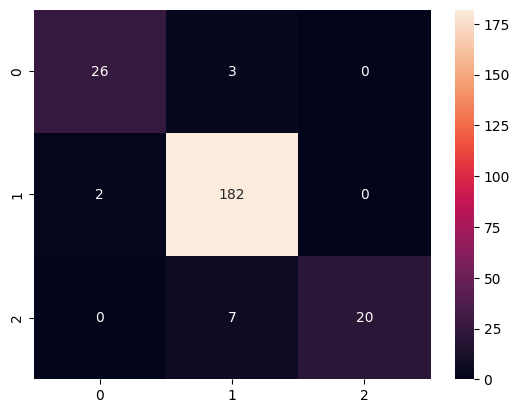

In [49]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()

## 9. Feature Importance (Key Findings)

Top factors influencing employee performance:

1. Environment Satisfaction
2. Monthly Income
3. Work-Life Balance
4. Job Role
5. Experience (Years at Company)

These factors play a major role in determining employee productivity.

---




Top 3 Important Features

In [50]:
importances = model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_df.head(10))

                         Feature  Importance
10    EmpEnvironmentSatisfaction    0.221368
17      EmpLastSalaryHikePercent    0.198401
24       YearsSinceLastPromotion    0.087936
0                      EmpNumber    0.054139
6                     EmpJobRole    0.037205
23  ExperienceYearsInCurrentRole    0.036284
5                  EmpDepartment    0.034896
11                 EmpHourlyRate    0.034104
1                            Age    0.030407
22  ExperienceYearsAtThisCompany    0.028367


## 10. Business Insights

* Employees with low satisfaction levels tend to underperform
* Compensation directly affects motivation
* Overworked employees show reduced efficiency
* Department-specific issues impact performance variations

---

📈 Department-wise Performance

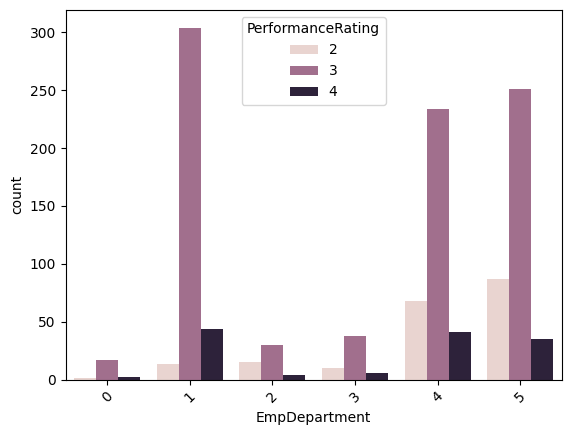

In [51]:
sns.countplot(x='EmpDepartment', hue='PerformanceRating', data=df)
plt.xticks(rotation=45)
plt.show()


## 11. Recommendations

### 1. Improve Work Environment

* Create a positive and supportive workplace culture
* Reduce workplace stress

### 2. Enhance Work-Life Balance

* Introduce flexible work schedules
* Reduce excessive workload

### 3. Revise Compensation Structure

* Offer performance-based incentives
* Ensure competitive salary packages

### 4. Employee Training & Development

* Conduct regular training programs
* Focus on skill development

### 5. Early Identification of Low Performers

* Use predictive model to identify risks
* Provide mentoring instead of penalizing

### 6. Department-Level Strategy

* Analyze low-performing departments
* Improve leadership and workload distribution

---

## 12. Conclusion

This project successfully identified the key factors affecting employee performance and built a predictive model to assist management decisions.

The findings suggest that improving employee satisfaction, compensation, and work-life balance can significantly enhance overall performance and organizational success.

---

## 13. Future Scope

* Deploy model as a real-time dashboard (Streamlit)
* Use advanced models (XGBoost, Gradient Boosting)
* Integrate with HR systems for continuous monitoring

---

## ✅ End of Report
